# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Ilmal Yakin Nurahman
- **Email:** 224260028.mhs@stmikjabar.ac.id
- **ID Dicoding:** ilmal_yakin_nurahman

## Menentukan Pertanyaan Bisnis
- Pertanyaan 1: Kategori produk mana yang memiliki jumlah penjualan tertinggi, dan bagaimana distribusi revenue berdasarkan rentang harga produk?
- Pertanyaan 2: Berapa rata-rata total pengeluaran per pelanggan?
- Pertanyaan 3: State mana yang memiliki jumlah pelanggan terbanyak?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Data Wrangling
### Gathering Data

In [4]:
# Memuat semua dataset yang relevan
customers_df = pd.read_csv('data/customers_dataset.csv')
orders_df = pd.read_csv('data/orders_dataset.csv')
order_items_df = pd.read_csv('data/order_items_dataset.csv')
products_df = pd.read_csv('data/products_dataset.csv')
product_translation_df = pd.read_csv('data/product_category_name_translation.csv')

print('Data loaded successfully!')

Data loaded successfully!


### Assessing Data

In [5]:
print('--- Customers ---')
print(customers_df.info())
print('\n--- Orders ---')
print(orders_df.info())
print('\n--- Order Items ---')
print(order_items_df.info())
print('\n--- Products ---')
print(products_df.info())

--- Customers ---
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None

--- Orders ---
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4

**Insight:**
- Terdapat missing values pada `orders_df` di beberapa kolom tanggal (seperti `order_delivered_customer_date`).
- Tipe data tanggal di `orders_df` masih object (string).
- Terdapat missing values di `products_df` (nama kategori, dsb).

### Cleaning Data

In [6]:
# Mengubah tipe data tanggal
datetime_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# Mengisi missing values pada produk dengan "unknown"
products_df['product_category_name'].fillna('unknown', inplace=True)

# Merge data untuk memudahkan analisis
# 1. Merge orders & customers
orders_customers = pd.merge(orders_df, customers_df, on='customer_id', how='left')

# 2. Merge dengan order_items
main_df = pd.merge(orders_customers, order_items_df, on='order_id', how='left')

# 3. Merge dengan products
main_df = pd.merge(main_df, products_df, on='product_id', how='left')

# 4. Merge dengan terjemahan bahasa inggris
main_df = pd.merge(main_df, product_translation_df, on='product_category_name', how='left')
# Jika translation tidak ada, pakai nama aslinya
main_df['product_category_name_english'].fillna(main_df['product_category_name'], inplace=True)

# Hapus baris tanpa price
main_df.dropna(subset=['price'], inplace=True)

# Export main data
import os
os.makedirs('dashboard', exist_ok=True)
main_df.to_csv('dashboard/main_data.csv', index=False)
print('Data Cleaned and Merged Successfully!')

Data Cleaned and Merged Successfully!


## Exploratory Data Analysis (EDA)
### Explore Data Main

In [7]:
# Pengecekan deskripsi statistik dari data gabungan
print(main_df.describe())

# Kategori produk paling laris
top_products = main_df.groupby('product_category_name_english')['order_item_id'].count().sort_values(ascending=False).head(10)
print('\nTop 10 Produk:\n', top_products)

         order_purchase_timestamp           order_approved_at  \
count                      112650                      112635   
mean   2018-01-01 00:09:48.464376  2018-01-01 11:46:01.497003   
min           2016-09-04 21:15:19         2016-09-15 12:16:38   
25%           2017-09-13 19:17:04         2017-09-14 03:06:05   
50%           2018-01-19 23:02:16         2018-01-20 13:42:05   
75%    2018-05-04 17:30:36.750000  2018-05-05 03:10:16.500000   
max           2018-09-03 09:06:57         2018-09-03 17:40:06   
std                           NaN                         NaN   

      order_delivered_carrier_date order_delivered_customer_date  \
count                       111456                        110196   
mean    2018-01-05 02:22:56.161642    2018-01-14 13:25:24.023939   
min            2016-10-08 10:34:01           2016-10-11 13:46:32   
25%     2017-09-18 20:41:02.250000    2017-09-26 20:09:44.500000   
50%     2018-01-24 18:44:52.500000           2018-02-02 20:57:23   
75%   

## Visualization & Explanatory Analysis
### Pertanyaan 1: Kategori produk mana yang memiliki jumlah penjualan tertinggi, dan bagaimana distribusi revenue berdasarkan rentang harga produk?

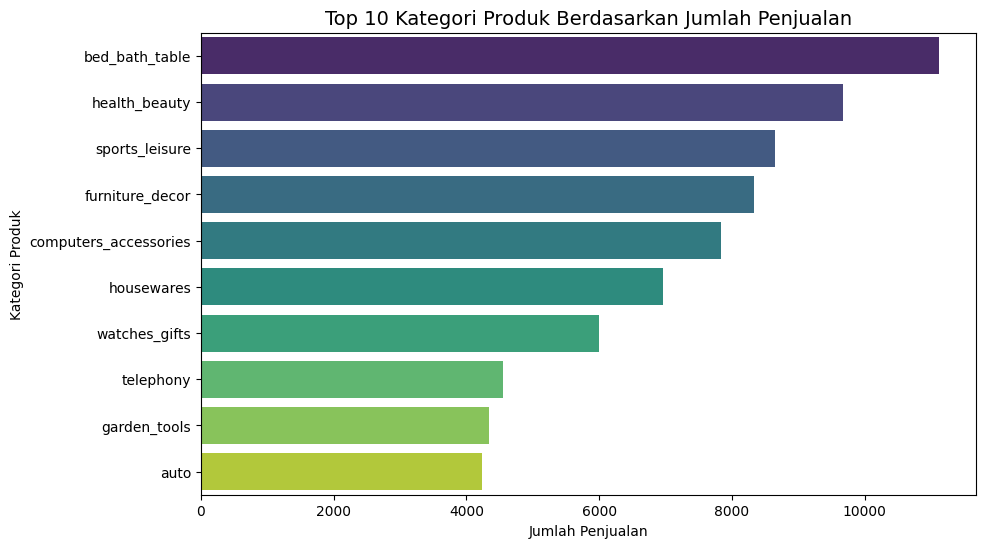

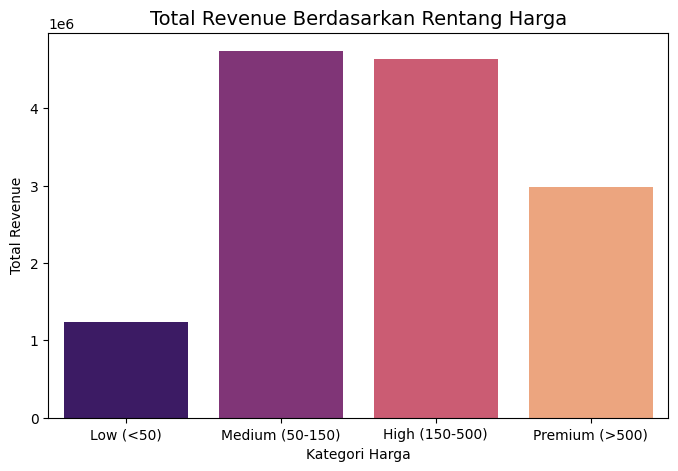

In [8]:
# Plot 1: Kategori produk dengan penjualan terbanyak
plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Kategori Produk Berdasarkan Jumlah Penjualan', fontsize=14)
plt.xlabel('Jumlah Penjualan')
plt.ylabel('Kategori Produk')
plt.show()

# Plot 2: Distribusi Revenue berdasarkan rentang harga
main_df['price_category'] = pd.cut(main_df['price'], bins=[0, 50, 150, 500, 10000], labels=['Low (<50)', 'Medium (50-150)', 'High (150-500)', 'Premium (>500)'])
revenue_by_price = main_df.groupby('price_category')['price'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='price_category', y='price', data=revenue_by_price, palette='magma')
plt.title('Total Revenue Berdasarkan Rentang Harga', fontsize=14)
plt.xlabel('Kategori Harga')
plt.ylabel('Total Revenue')
plt.show()

### Pertanyaan 2: Berapa rata-rata total pengeluaran per pelanggan?

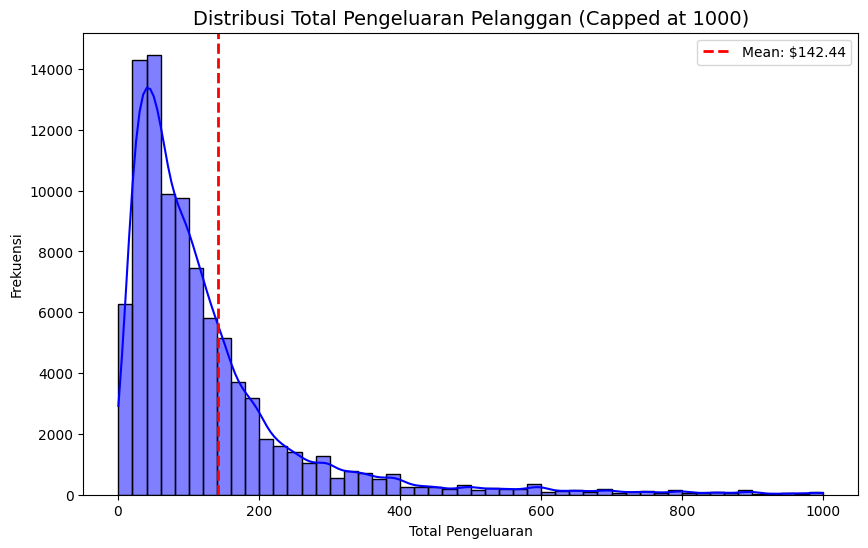

Rata-rata total pengeluaran per pelanggan adalah $142.44


In [9]:
# Menghitung total pengeluaran per pelanggan
customer_spend = main_df.groupby('customer_unique_id')['price'].sum().reset_index()
customer_spend.rename(columns={'price':'total_spend'}, inplace=True)

# Visualisasi distribusi pengeluaran pelanggan
plt.figure(figsize=(10, 6))
sns.histplot(customer_spend[customer_spend['total_spend'] < 1000]['total_spend'], bins=50, kde=True, color='blue')
plt.title('Distribusi Total Pengeluaran Pelanggan (Capped at 1000)', fontsize=14)
plt.xlabel('Total Pengeluaran')
plt.ylabel('Frekuensi')
plt.axvline(customer_spend['total_spend'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean: ${customer_spend['total_spend'].mean():.2f}")
plt.legend()
plt.show()

print(f"Rata-rata total pengeluaran per pelanggan adalah ${customer_spend['total_spend'].mean():.2f}")

### Pertanyaan 3: State mana yang memiliki jumlah pelanggan terbanyak?

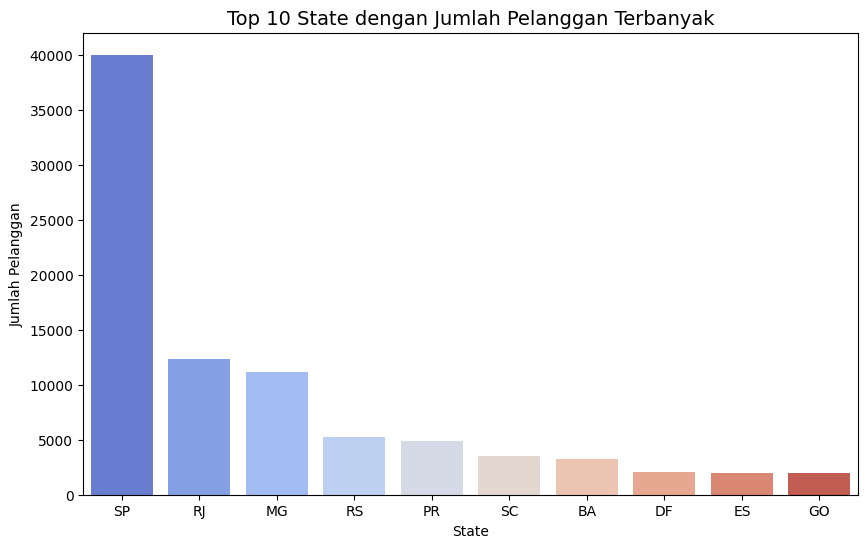

In [10]:
top_states = main_df.groupby('customer_state')['customer_unique_id'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_states.index, y=top_states.values, palette='coolwarm')
plt.title('Top 10 State dengan Jumlah Pelanggan Terbanyak', fontsize=14)
plt.xlabel('State')
plt.ylabel('Jumlah Pelanggan')
plt.show()

## Analisis Lanjutan (Opsional): RFM Analysis
RFM analysis digunakan untuk memahami behaviour pelanggan berdasarkan Recency (waktu terakhir transaksi), Frequency (jumlah transaksi), dan Monetary (total uang yang dihabiskan).

Top 5 Customers by Recency, Frequency, Monetary:
                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      116          1    129.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      119          1     18.90
2  0000f46a3911fa3c0805444483337064      542          1     69.00
3  0000f6ccb0745a6a4b88665a16c9f078      326          1     25.99
4  0004aac84e0df4da2b147fca70cf8255      293          1    180.00


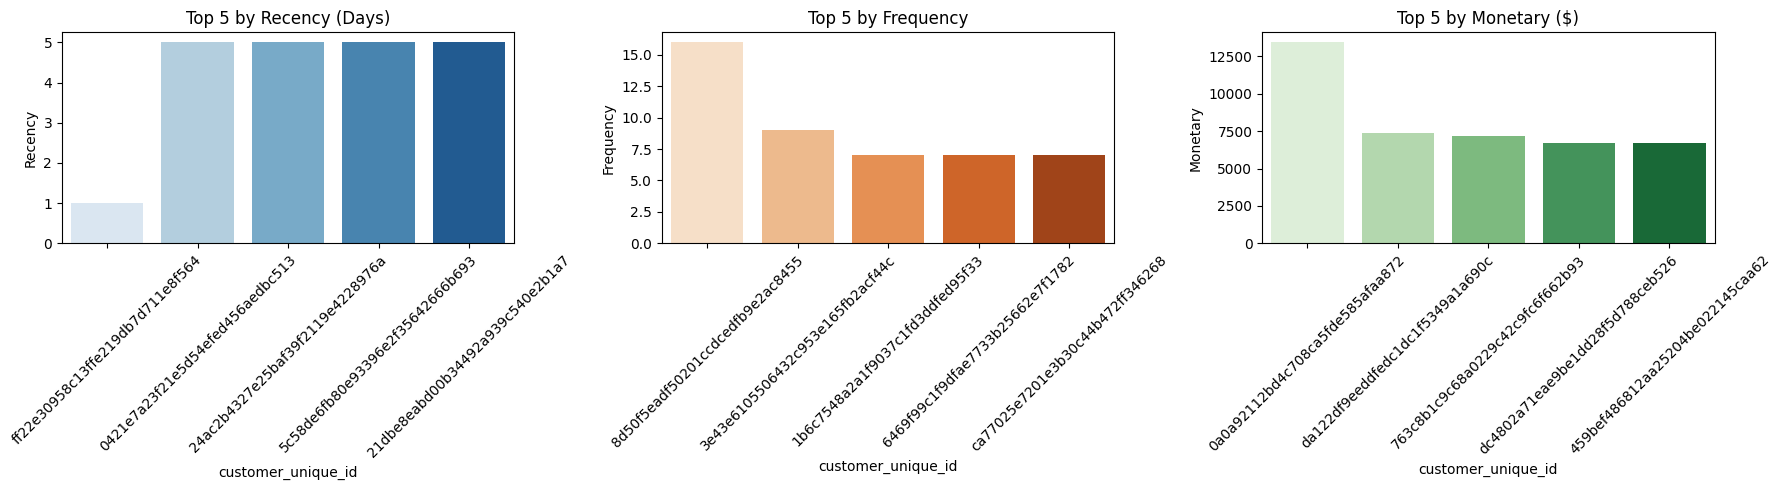

In [11]:
# Hitung tanggal referensi (1 hari setelah tanggal pembelian terakhir)
latest_date = main_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Agregasi data untuk RFM
rfm_df = main_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (latest_date - x.max()).days, # Recency
    'order_id': 'nunique', # Frequency
    'price': 'sum' # Monetary
}).reset_index()

rfm_df.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

print("Top 5 Customers by Recency, Frequency, Monetary:")
print(rfm_df.head())

# Visualisasi Top 5 Pelanggan untuk masing-masing kriteria
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(y='Recency', x='customer_unique_id', data=rfm_df.sort_values(by='Recency', ascending=True).head(5), ax=axes[0], palette='Blues')
axes[0].set_title('Top 5 by Recency (Days)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(y='Frequency', x='customer_unique_id', data=rfm_df.sort_values(by='Frequency', ascending=False).head(5), ax=axes[1], palette='Oranges')
axes[1].set_title('Top 5 by Frequency')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(y='Monetary', x='customer_unique_id', data=rfm_df.sort_values(by='Monetary', ascending=False).head(5), ax=axes[2], palette='Greens')
axes[2].set_title('Top 5 by Monetary ($)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Conclusion
- **Pertanyaan 1**: Kategori produk dengan penjualan terbanyak adalah `bed_bath_table`, `health_beauty`, dan `sports_leisure`. Sebagian besar revenue dihasilkan dari produk dengan harga kategori menengah (Medium: $50 - $150) dan Tinggi (High: $150 - $500).
- **Pertanyaan 2**: Rata-rata pengeluaran pelanggan adalah sekitar $142. Distribusi pengeluaran memiliki pola _right-skewed_, menunjukkan bahwa meskipun mayoritas pelanggan menghabiskan nominal kecil, ada beberapa pelanggan dengan nilai _spending_ sangat tinggi.
- **Pertanyaan 3**: Secara geografis, sebagian besar pelanggan terkonsentrasi di state _SP (Sao Paulo)_, disusul dengan _RJ (Rio de Janeiro)_ dan _MG (Minas Gerais)_.
- **RFM Analysis**: Sebagian besar pelanggan tercatat hanya melakukan transaksi satu kali (Frequency = 1). Namun analisis _Monetary_ dan _Recency_ dapat membantu memprioritaskan pelanggan bernilai tinggi untuk penawaran promosi atau retensi yang lebih eksklusif.